Task 3: Historical temperature data


Now you want to compare the 2025 temperatures to temperatures measured 100
years earlier.

Get these temperatures from the database.

Plot the new and the old temperatures in the same plot, still nicely formatted

Generate a summary table as for task 1, where you display data from both the new

and the old temperatures.

plot 1 (task1)

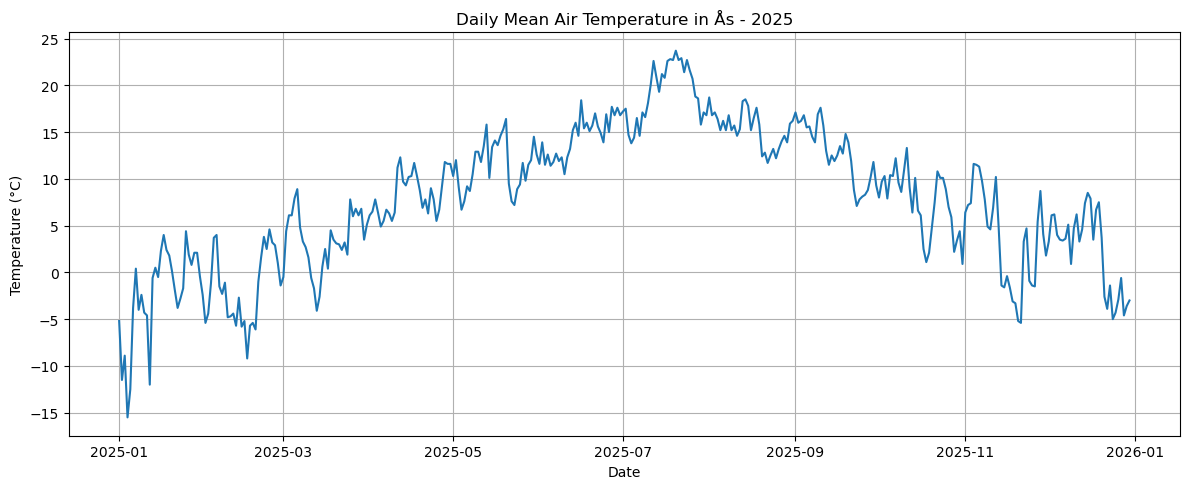

In [14]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from frost_id import client_id

client_id = client_id

#Requests the daily mean air temperture for all of 2025
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
'sources': 'SN17850',
'elements': 'mean(air_temperature P1D)',
'referencetime': '2025-01-01/2025-12-31',
}

# Issue an HTTP GET request
r = requests.get(endpoint, parameters, auth=(client_id,''))
# Extract JSON data
data = r.json()

observations = data["data"]

df = pd.DataFrame(observations)



df["temperature"] = df["observations"].apply(
    lambda x: x[0]["value"]
)

df["time"] = pd.to_datetime(df["referenceTime"])



df["temperature"] = df["observations"].apply(
    lambda x: x[0]["value"]
)

df["time"] = pd.to_datetime(df["referenceTime"])

plt.figure(figsize=(12, 5))

plt.plot(df["time"], df["temperature"])

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Mean Air Temperature in Ås - 2025")

plt.grid(True)
plt.tight_layout()
plt.show()



plot 2 (task3)

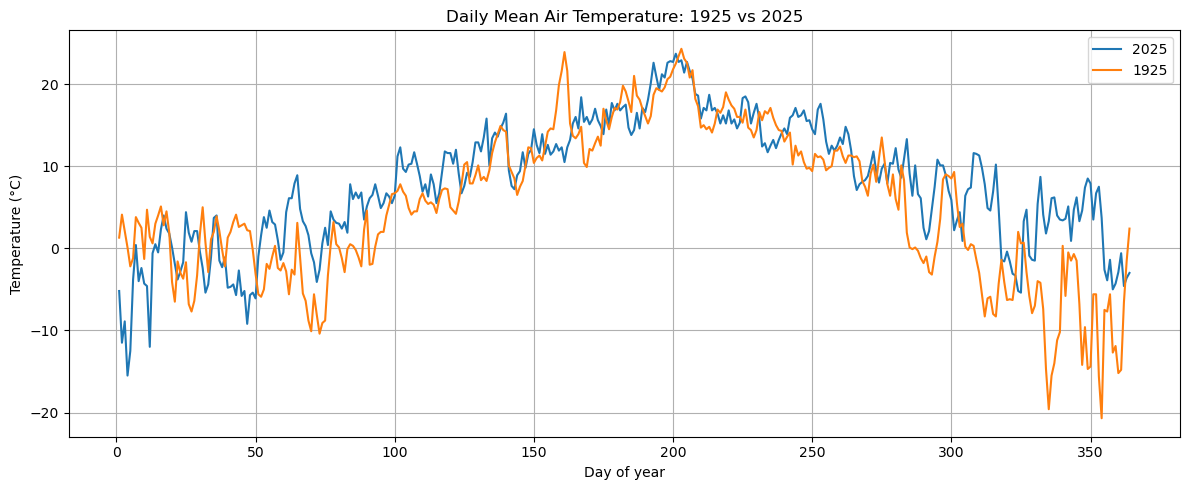

In [15]:
# Requests the daily mean air temperature for all of 1925
endpoint = 'https://frost.met.no/observations/v0.jsonld'

parameters_1925 = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '1925-01-01/1925-12-31',
}

# Issue an HTTP GET request
r_1925 = requests.get(
    endpoint,
    parameters_1925,
    auth=(client_id, '')
)

# Extract JSON data
data_1925 = r_1925.json()

observations_1925 = data_1925["data"]

df_1925 = pd.DataFrame(observations_1925)

df_1925["temperature"] = df_1925["observations"].apply(
    lambda x: x[0]["value"]
)

df_1925["time"] = pd.to_datetime(df_1925["referenceTime"])

df["day"] = df["time"].dt.dayofyear
df_1925["day"] = df_1925["time"].dt.dayofyear

# Create a new figure for the comparison plot
plt.figure(figsize=(12, 5))

plt.plot(
    df["day"],
    df["temperature"],
    label="2025"
)

plt.plot(
    df_1925["day"],
    df_1925["temperature"],
    label="1925"
)

plt.xlabel("Day of year")
plt.ylabel("Temperature (°C)")
plt.title("Daily Mean Air Temperature: 1925 vs 2025")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
#Tabell
summary_table = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Min", "Max"],
    "1925 (°C)": [
        df_1925["temperature"].mean(),
        df_1925["temperature"].median(),
        df_1925["temperature"].min(),
        df_1925["temperature"].max()
    ],
    "2025 (°C)": [
        df["temperature"].mean(),
        df["temperature"].median(),
        df["temperature"].min(),
        df["temperature"].max()
    ]
})

print(summary_table)

  Statistic  1925 (°C)  2025 (°C)
0      Mean    5.31044   7.902747
1    Median    5.30000   8.400000
2       Min  -20.70000 -15.500000
3       Max   24.30000  23.700000
